# TM10007 Machine Learning Group 10 Liver 

In [8]:
# Run this to use from colab environment
!pip install -q --upgrade git+https://github.com/jveenland/tm10007_ml.git

## Importing packages 


In [1]:
# General packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets as ds
import seaborn as sns

# Classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import svm


# Statistics
from sklearn import model_selection
from sklearn import metrics
from sklearn import svm
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import KFold, train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, auc
from scipy.stats import zscore, shapiro
from sklearn.pipeline import Pipeline

## Data loading 

Below are functions to load the dataset of your choice. After that, it is all up to you to create and evaluate a classification method. Beware, there may be missing values in these datasets. Good luck!

In [2]:
from worcliver.load_data import load_data

# Load the data
data = load_data()

# Replace the labels with binary labels
data_binary = data.copy()
data_binary["label"] = data_binary["label"].map({"malignant": 1, "benign": 0})

# Print number of samples and columns
print(f"The number of samples: {len(data_binary.index)}")
print(f"The number of columns: {len(data_binary.columns)}")
print(f"The number of malignant samples: {sum(data_binary['label']==1)}")
print(f"The number of benign samples: {sum(data_binary['label']==0)}")

The number of samples: 186
The number of columns: 494
The number of malignant samples: 94
The number of benign samples: 92


## Data preprocessing

In [3]:
# Checking for duplicate samples
duplicate_samples = data_binary[data_binary.duplicated()]
if len(duplicate_samples) > 0:
    print(f"Number of duplicate rows: {len(duplicate_samples)}")
else:
    print("No duplicate sample found.")   
# Remove duplicate samples
data_cleaned = data_binary.drop_duplicates()

# Checking for duplicate features
duplicate_features = data_cleaned.columns[data_cleaned.columns.duplicated()]
if len(duplicate_features) > 0:
    print(f"Number of duplicate features: {len(duplicate_features)}")
    print("Duplicate feature names:")
    print(list(duplicate_features))
    # Remove duplicate features
    data_cleaned = data_cleaned.loc[:, ~data_cleaned.columns.duplicated()]   
else:
    print("No duplicate features found.")

# Checking for missing data
# Check for infinite values
print(f"Amount of infinite data: {data_cleaned.map(np.isinf).sum().sum()}")
# Check for missing values
print(f"Amount of missing data: {data_cleaned.isna().sum().sum()}")


No duplicate sample found.
No duplicate features found.
Amount of infinite data: 0
Amount of missing data: 0


## Data splitting


In [4]:
# Split the dataset in features and labels
X = data_cleaned.drop(columns=["label"])
y = data_cleaned["label"]

# Split the dataset in train and test part
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print the number of samples in the train and test set
print(f"The number of samples in the train set: {len(X_train.index)}")
print(f"The number of samples in the test set: {len(X_test.index)}")


The number of samples in the train set: 148
The number of samples in the test set: 38


## Scaling 
First check the distribution of the data, we check for normal and not normal distribution and we check the data on outliers

In [5]:
# Checking the distribution of the columns of the dataset and filling in missing values
alpha = 0.05
nd_columns_train = 0
nnd_columns_train = 0

for column in X_train:
    if X_train[column].min() != X_train[column].max():
        # Perform Shapiro-Wilk test for normality
        stat, p = shapiro(X_train[column].dropna())
        # Interpret the result
        if p > alpha:
            nd_columns_train += 1
            if X_train[column].isna().sum() > 0:
                # Fill missing values with the mean of the column
                X_train[column].fillna(X_train[column].mean(), inplace=True)
        else:
            nnd_columns_train += 1
            if X_train[column].isna().sum() > 0:
                # Fill missing values with the median of the column
                X_train[column].fillna(X_train[column].median(), inplace=True)
print(f"Number of normal distributed columns in the train set: {nd_columns_train}")
print(f"Number of non-normal distributed columns in the train set: {nnd_columns_train}")
    

Number of normal distributed columns in the train set: 53
Number of non-normal distributed columns in the train set: 423


In [6]:
# Calculating presence and number of outliers
columns_many_outliers_count = 0

for column in X_train:
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1

    outliers = X_train[(X_train[column] < (Q1 - 1.5 * IQR)) | (X_train[column] > (Q3 + 1.5 * IQR))]
    outliers_count = outliers.shape[0]

    if outliers_count > 0.05 * X_train.shape[0]:
        columns_many_outliers_count += 1

perc_columns_many_outliers = (columns_many_outliers_count / len(X_train.columns)) * 100
print(f"Number of columns with many outliers: {columns_many_outliers_count}/{len(X_train.columns)} = {perc_columns_many_outliers:.2f}%")

Number of columns with many outliers: 166/493 = 33.67%


### Scaling the data

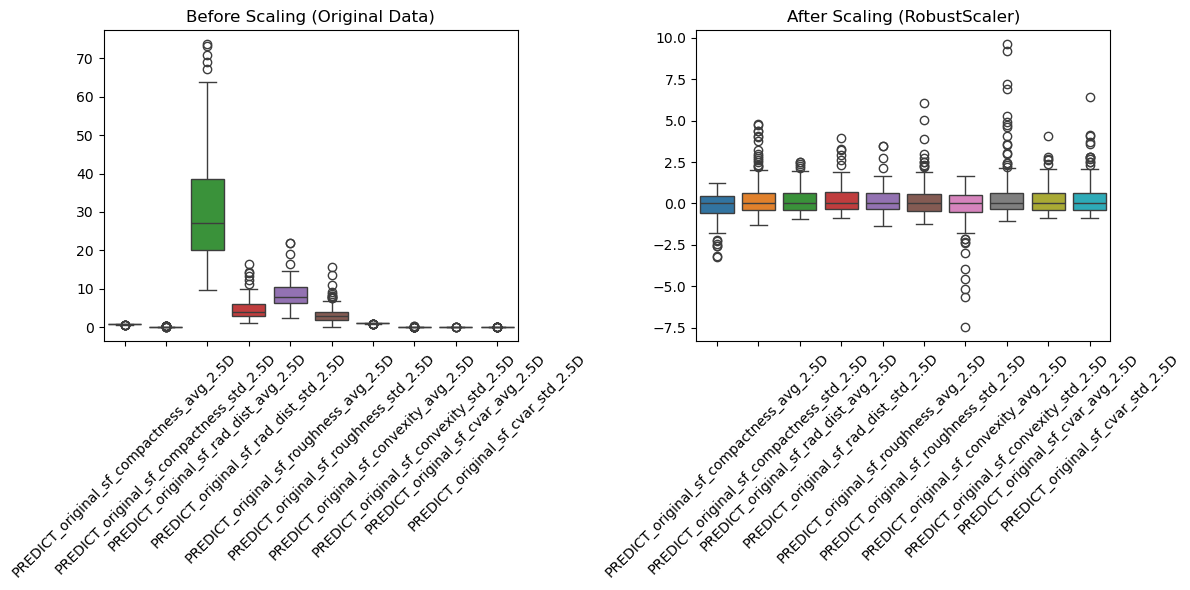

In [7]:
scaler = RobustScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled) 

features_to_plot = X_train.columns[:10] 
# Create a figure with two subplots
plt.figure(figsize=(12, 6))

# Plot original (unscaled) data
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train[features_to_plot])
plt.title("Before Scaling (Original Data)")
plt.xticks(rotation=45)

# Plot scaled data
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled[features_to_plot])
plt.title("After Scaling (RobustScaler)")
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()


### Feature selection

c:\Users\caspe\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 76  77  84  85  90  96  97 103 110 467 474 475 480 487 488] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\caspe\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Geselecteerde features na RFECV: ['PREDICT_original_sf_area_max_2.5D', 'PREDICT_original_sf_area_min_2.5D', 'PREDICT_original_hf_range', 'PREDICT_original_logf_kurtosis_sigma1', 'PREDICT_original_logf_peak_sigma1', 'PREDICT_original_logf_quartile_range_sigma1', 'PREDICT_original_tf_LBP_quartile_range_R8_P24', 'PREDICT_original_tf_Gabor_min_F0.05_A2.36', 'PREDICT_original_tf_Gabor_peak_F0.05_A2.36']
Aantal geselecteerde features: 9
Model accuraatheid (beste cross-val score): 0.8169274537695591


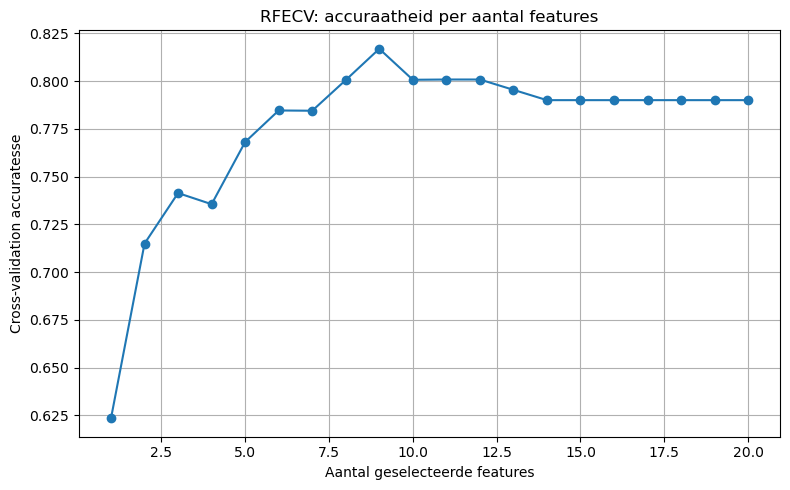

c:\Users\caspe\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 76  77  84  85  90  96  97 103 110 467 474 475 480 487 488] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\caspe\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\caspe\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 76  77  84  85  90  96  97 103 110 467 474 475 480 487 488] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\caspe\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\caspe\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: User

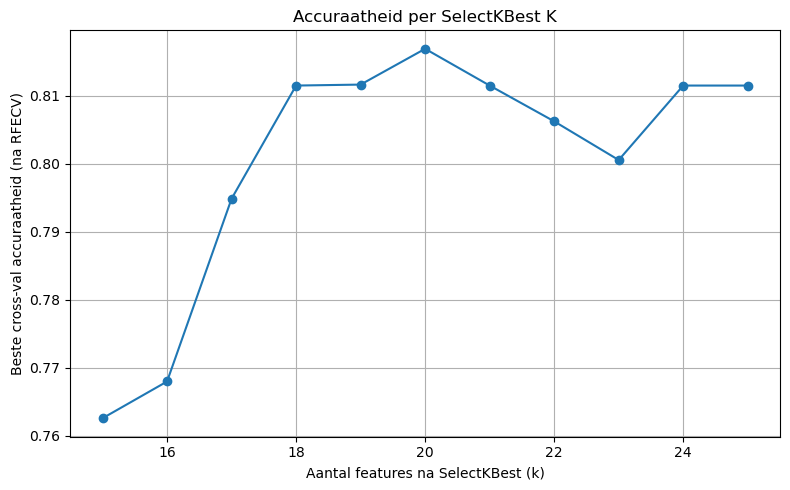

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, RFECV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# 1. Data inladen
df = pd.read_csv(r"worcliver\Liver_radiomicFeatures.csv")

# 2. X en y splitsen — pas 'label' aan als je kolom anders heet
X = df.drop(columns=["ID", "label"])  # alleen numerieke features
y = df["label"]

# 3. Univariate selectie (top K features, hier K=20 als startpunt)
k = 20
univariate_selector = SelectKBest(score_func=f_classif, k=k)
X_selected = univariate_selector.fit_transform(X, y)
selected_feature_names = X.columns[univariate_selector.get_support()]

# 4. RFECV met logistic regression (L2 is standaard penalty)
model = LogisticRegression(max_iter=1000)
rfecv = RFECV(estimator=model, step=1, cv=StratifiedKFold(5), scoring="accuracy", n_jobs=-1)

# 5. Pipeline met scaling + RFECV
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("feature_selection", rfecv),
    ("classifier", LogisticRegression(max_iter=1000))
])

# 6. Fit pipeline op de eerder geselecteerde features
pipeline.fit(X_selected, y)

# 7. Resultaten
final_features = selected_feature_names[rfecv.support_]
print("Geselecteerde features na RFECV:", list(final_features))
print("Aantal geselecteerde features:", len(final_features))
print("Model accuraatheid (beste cross-val score):", rfecv.cv_results_['mean_test_score'][rfecv.n_features_ - 1])

# 8. plotten van de resultaten
import matplotlib.pyplot as plt

# Plot de gemiddelde cross-val scores per aantal features
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
         rfecv.cv_results_['mean_test_score'],
         marker='o')
plt.xlabel("Aantal geselecteerde features")
plt.ylabel("Cross-validation accuratesse")
plt.title("RFECV: accuraatheid per aantal features")
plt.grid(True)
plt.tight_layout()
plt.show()

# 9. plot accuraatheid vs K

import matplotlib.pyplot as plt

k_values = [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]  # Pas dit aan als je meer resolutie wilt
accuracy_scores = []

for k in k_values:
    # 1. SelectKBest
    univariate_selector = SelectKBest(score_func=f_classif, k=k)
    X_selected = univariate_selector.fit_transform(X, y)
    selected_feature_names = X.columns[univariate_selector.get_support()]
    
    # 2. RFECV
    model = LogisticRegression(max_iter=1000)
    rfecv = RFECV(estimator=model, step=1, cv=StratifiedKFold(5), scoring="accuracy", n_jobs=-1)
    
    # 3. Pipeline
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("feature_selection", rfecv),
        ("classifier", LogisticRegression(max_iter=1000))
    ])
    
    # 4. Fit pipeline
    pipeline.fit(X_selected, y)
    
    # 5. Bewaar de beste score van RFECV
    score = rfecv.cv_results_['mean_test_score'][rfecv.n_features_ - 1]
    accuracy_scores.append(score)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracy_scores, marker='o')
plt.xlabel("Aantal features na SelectKBest (k)")
plt.ylabel("Beste cross-val accuraatheid (na RFECV)")
plt.title("Accuraatheid per SelectKBest K")
plt.grid(True)
plt.tight_layout()
plt.show()


'''probeer nog even die andere methodes die chatgpt gaf, dus SVM en RandomForest
enzo. ff naarboven scrollen in de chat.'''